# IS4487 Week 11 - Practice Code

This notebook is designed to help you follow along with the **Week 11 Lecture and Reading**, introducing you to Regression.

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Create a linear regression to predict a numeric value
- Visualize the regression line

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_11_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Apple (AAPL) Stock Price Prediction
We will use historical stock prices, in addition to two calculated metrics, to predict the stock price on the following day of trading.

Variables include:

| Feature     | Description                                          | Type        |
| ----------- | ---------------------------------------------------- | ----------- |
| `Open`       | Beginning stock price on the given day                                  | Numeric     |
| `High`       | Maximum stock price on the given day     | Numeric |
| `Low`   | Minimum  stock price on the given day              | Numeric |
| `Close` | Closing stock price on the given day | Numeric |
| `Volume`   |  Number of shared traded on the given day                           | Numeric |
| `Direction`   | Comparison of open to close price                         | Numeric |
| `RSI`      | Relative Strength Index.  RSI compares the average gains to the average losses in the last 14 trading days                        | Numeric |
| `SMA_5`   | 5-period Simple Moving Average     | Numeric     |
| `Next_Day_Closing`   | Closing stock price on the next trading day         | Numeric |

Your task is to predict `Next_Day_Closing`,  the stock price on the following day of trading.

### Linear Regression

We will first build a linear regression model to predict y = `Next_Day_Closing`, using X = features in the dataset, and then compare the prediction to the actual values in a plot.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Load the dataset
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/aapl_stock_prices.csv"
df = pd.read_csv(url, sep=',')

In [2]:
#Preview the data
df.head()

,Date,Open,High,Low,Close,Volume,SMA_5,RSI,Direction,Next_Day_Closing
0,1/1/2024,190.08,191.26,189.10,190.14,53020510,NaN,NaN,Down,189.86
1,1/2/2024,190.08,190.42,189.48,189.86,42711634,NaN,NaN,Up,191.44
2,1/3/2024,191.38,192.61,190.57,191.44,50797566,NaN,NaN,Up,193.11
3,1/4/2024,192.83,194.31,191.40,193.11,37414802,NaN,NaN,Down,192.31
4,1/5/2024,192.28,193.29,191.39,192.31,51593301,191.37,NaN,Down,192.14


Prepare Data

In [3]:
# Select features and target for stock price prediction
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'RSI']
target = 'Next_Day_Closing'

# Drop rows with missing values in selected features or target
df_cleaned = df.dropna(subset=features + [target])

# Define features (X) and target (y)
X = df_cleaned[features]
y = df_cleaned[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (228, 7)
X_test shape: (58, 7)
y_train shape: (228,)
y_test shape: (58,)


Create Model

In [4]:
# Create and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

Evaluate Model

In [5]:
# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

R² score: 0.90
Mean Squared Error: 1.54


Create Visualization

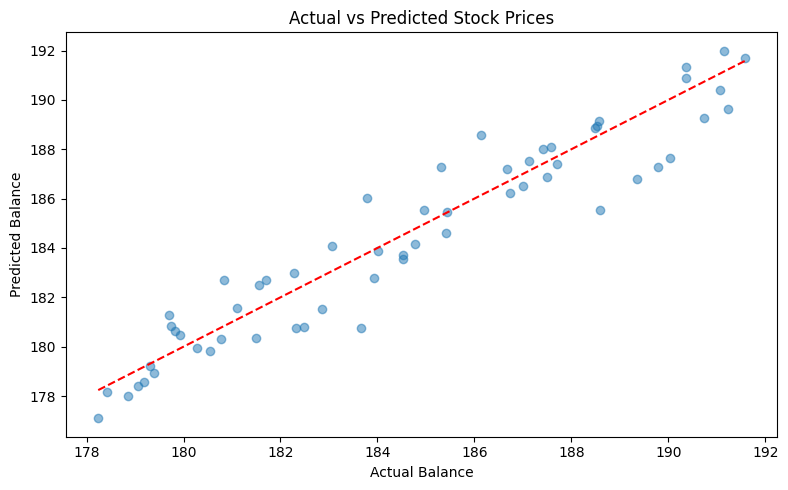

In [6]:
# Plot actual vs predicted balances
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Balance')
plt.ylabel('Predicted Balance')
plt.title('Actual vs Predicted Stock Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.tight_layout()
plt.show()